# MNIST Ziffernerkennung – Einfache Version

Ein minimales neuronales Netz zur Erkennung handgeschriebener Ziffern.

In [28]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print(f'TensorFlow Version: {tf.__version__}')

TensorFlow Version: 2.16.2


## 1. Daten laden und vorbereiten

In [29]:
# MNIST laden
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalisieren (0-255 -> 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f'Training: {x_train.shape}, Test: {x_test.shape}')

Training: (60000, 28, 28), Test: (10000, 28, 28)


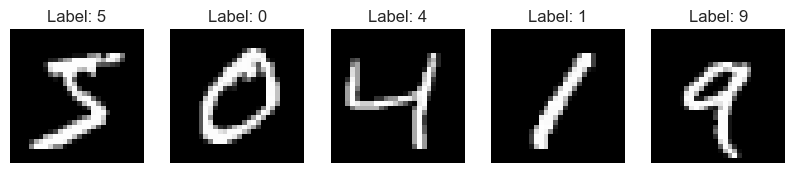

In [30]:
# Beispielbilder anzeigen
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.show()

## 2. Modell erstellen

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),  # 20% der Neuronen zufällig deaktivieren
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [32]:
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 802us/step - accuracy: 0.9072 - loss: 0.3185 - val_accuracy: 0.9663 - val_loss: 0.1265
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 653us/step - accuracy: 0.9549 - loss: 0.1506 - val_accuracy: 0.9695 - val_loss: 0.1089
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.9656 - loss: 0.1125 - val_accuracy: 0.9770 - val_loss: 0.0804
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.9714 - loss: 0.0912 - val_accuracy: 0.9778 - val_loss: 0.0729
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 655us/step - accuracy: 0.9754 - loss: 0.0779 - val_accuracy: 0.9782 - val_loss: 0.0748


## 4. Evaluation

In [33]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')

Test Accuracy: 97.54%


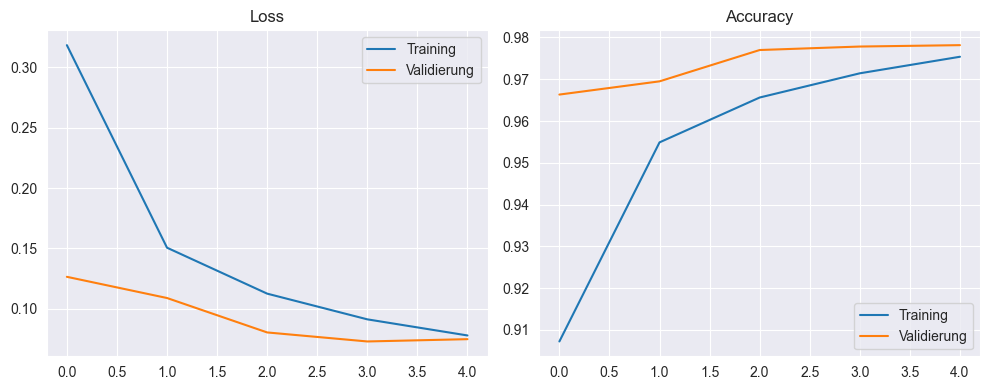

In [34]:
# Trainingsverlauf
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validierung')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validierung')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 5. Vorhersagen testen

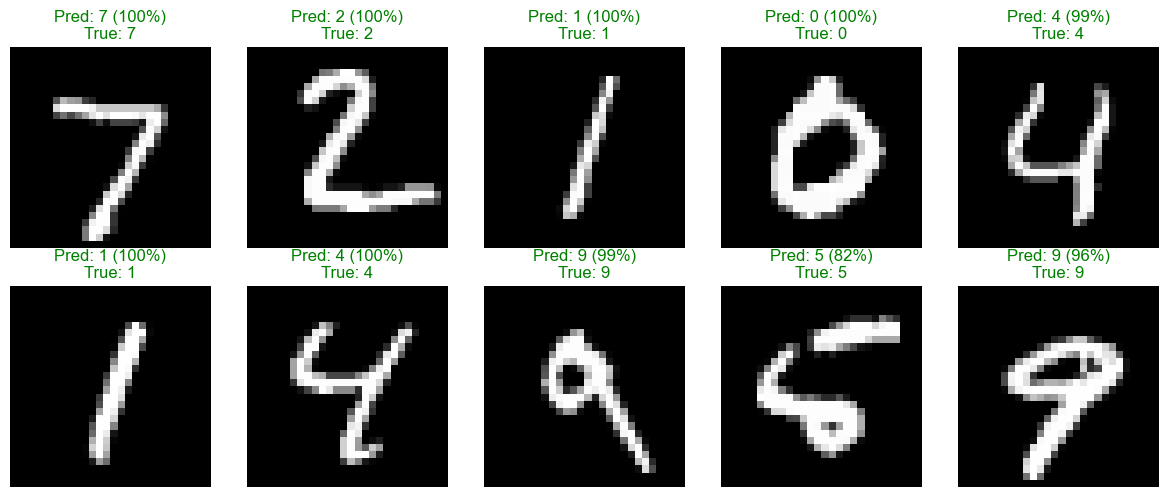

In [35]:
# Zufällige Testbilder vorhersagen
predictions = model.predict(x_test[:10], verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i], cmap='gray')
    pred = np.argmax(predictions[i])
    conf = predictions[i][pred] * 100
    color = 'green' if pred == y_test[i] else 'red'
    ax.set_title(f'Pred: {pred} ({conf:.0f}%)\nTrue: {y_test[i]}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Modell speichern & laden

In [36]:
# Speichern
model.save('mnist_simple.keras')
print('Modell gespeichert!')

# Laden
loaded_model = tf.keras.models.load_model('mnist_simple.keras')
print('Modell geladen!')

Modell gespeichert!
Modell geladen!
